In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import preprocessing
import seaborn as sb
%matplotlib inline
import keras
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adadelta, RMSprop,SGD,Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from keras.utils import to_categorical
import warnings
warnings.filterwarnings("ignore")
keras.backend.backend()


Using TensorFlow backend.


'tensorflow'

In [2]:
data = pd.HDFStore('bdv-data.h5')
print(data.keys())
df = data['all_nine_years']
data.close()

['/all_nine_years', '/flat', '/gifi', '/gifi8_four_classification']


In [3]:
df.head(36)

total_assets_less_cur._liab._th_gbp  net_assets_th_gbp  \
bv_id      year                                                           
GB07114838 2011                               -0.505             -0.505   
           2012                               -2.561             -2.561   
           2013                                7.658              7.658   
           2014                               21.344             21.344   
           2015                               61.440             19.280   
           2016                               22.798             22.798   
           2017                               39.533             39.533   
           2018                               44.736             44.736   
           2019                               39.009             39.009   
GB07114865 2011                               13.830             -6.493   
           2012                                9.066            -11.257   
           2013                                9.066            -11.257   
           2014                                9.066            -11.257   
           2015                               36.972              8.915   
           2016                              135.507            135.507   
           2017                              112.487            112.487   
           2018                              120.646            120.646   
           2019                               73.569             54.569   
GB07114884 2011                                0.002              0.002   
           2012                                0.002              0.002   
           2013                               -2.995             -2.995   
           2014                               -7.265             -7.265   
           2015                               64.588              1.101   
           2016                               60.029            -13.479   
           2017                               27.708            -37.746   
           2018                               35.040            -23.566   
           2019                               46.494             -5.692   
GB07114896 2011                               16.029             -3.136   
           2012                               12.939             -2.147   
           2013                               -5.465             -9.465   
           2014                               -0.361             -3.461   
           2015                                7.767             -2.035   
           2016                                7.864             -3.578   
           2017                                9.764              3.785   
           2018                                0.193             -1.952   
           2019                                0.193             -1.952   

                 net_tangible_assets_(liab.)_th_gbp  total_assets_th_gbp  \
bv_id      year                                                            
GB07114838 2011                              -0.505               32.892   
           2012                              -2.561               33.273   
           2013                               7.658               59.282   
           2014                              21.344               66.893   
           2015                              61.440               61.440   
           2016                              22.798               69.024   
           2017                              39.533               53.914   
           2018                              44.736               78.849   
           2019                              39.009               77.946   
GB07114865 2011                              13.830               16.028   
           2012                               5.052               10.592   
           2013                               5.052               10.592   
           2014                               5.052               10.592   
           2015           

In [4]:
df.shape

(63657, 177)

In [5]:
_y = 'solvency_ratio_(asset_based)_(%)'
Y = pd.DataFrame(df.pop(_y))
Y.fillna(Y.mean(),inplace=True)
Y.head(36)

solvency_ratio_(asset_based)_(%)
bv_id      year                                  
GB07114838 2011                         -1.535328
           2012                         -7.696931
           2013                         12.917918
           2014                         31.907673
           2015                         31.380208
           2016                         33.029091
           2017                         73.326038
           2018                         56.736293
           2019                         50.046186
GB07114865 2011                        -40.510357
           2012                         30.043758
           2013                         30.043758
           2014                         30.043758
           2015                         24.112842
           2016                         78.511089
           2017                         73.484893
           2018                         74.963806
           2019                         16.953634
GB07114884 2011                        100.000000
           2012                        100.000000
           2013                        -21.543663
           2014                        -20.364401
           2015                          1.129300
           2016                        -17.197208
           2017                        -95.823919
           2018                        -50.258051
           2019                        -10.057959
GB07114896 2011                        -19.564539
           2012                         -9.013434
           2013                        -49.508317
           2014                        -24.243486
           2015                        -17.524974
           2016                        -33.824920
           2017                         38.764850
           2018                         30.043758
           2019                         30.043758

In [6]:
#np.log(df.shift(-1)/df)
Y=Y.assign(growth_of_y=Y.shift(-1) - Y)
#Y=Y.assign(up=(Y.shift(-1) - Y > 0))
Y.head(8)

solvency_ratio_(asset_based)_(%)  growth_of_y
bv_id      year                                               
GB07114838 2011                         -1.535328    -6.161604
           2012                         -7.696931    20.614849
           2013                         12.917918    18.989756
           2014                         31.907673    -0.527465
           2015                         31.380208     1.648883
           2016                         33.029091    40.296946
           2017                         73.326038   -16.589744
           2018                         56.736293    -6.690108

In [7]:
Y=Y.assign(up=Y.growth_of_y>0)
Y.drop(index=2019, level=1, inplace=True)
Y.head(48)

solvency_ratio_(asset_based)_(%)  growth_of_y     up
bv_id      year                                                      
GB07114838 2011                         -1.535328    -6.161604  False
           2012                         -7.696931    20.614849   True
           2013                         12.917918    18.989756   True
           2014                         31.907673    -0.527465  False
           2015                         31.380208     1.648883   True
           2016                         33.029091    40.296946   True
           2017                         73.326038   -16.589744  False
           2018                         56.736293    -6.690108  False
GB07114865 2011                        -40.510357    70.554115   True
           2012                         30.043758     0.000000  False
           2013                         30.043758     0.000000  False
           2014                         30.043758    -5.930916  False
           2015                         24.112842    54.398247   True
           2016                         78.511089    -5.026196  False
           2017                         73.484893     1.478913   True
           2018                         74.963806   -58.010172  False
GB07114884 2011                        100.000000     0.000000  False
           2012                        100.000000  -121.543663  False
           2013                        -21.543663     1.179262   True
           2014                        -20.364401    21.493701   True
           2015                          1.129300   -18.326509  False
           2016                        -17.197208   -78.626711  False
           2017                        -95.823919    45.565868   True
           2018                        -50.258051    40.200092   True
GB07114896 2011                        -19.564539    10.551105   True
           2012                         -9.013434   -40.494883  False
           2013                        -49.508317    25.264831   True
           2014                        -24.243486     6.718511   True
           2015                        -17.524974   -16.299945  False
           2016                        -33.824920    72.589770   True
           2017                         38.764850    -8.721093  False
           2018                         30.043758     0.000000  False
GB07114911 2011                         24.310552     1.714484   True
           2012                         26.025036    13.063669   True
           2013                         39.088705    50.975496   True
           2014                         90.064201   -10.064201  False
           2015                         80.000000    10.862944   True
           2016                         90.862944     5.402461   True
           2017                         96.265405    -0.360037  False
           2018                         95.905369   -11.641607  False
GB07114950 2011                         30.043758    69.956242   True
           2012                        100.000000     0.000000  False
           2013                        100.000000     0.000000  False
           2014                        100.000000     0.000000  False
           2015                        100.000000     0.000000  False
           2016                        100.000000     0.000000  False
           2017                        100.000000     0.000000  False
           2018                        100.000000     0.000000  False

In [8]:
df = pd.DataFrame(df, index=Y.index)
df.reset_index(drop=True, inplace=True)
df.head(48)

,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp,net_tangible_assets_(liab.)_th_gbp,total_assets_th_gbp,net_current_assets_(working_capital)_th_gbp,shareholders_funds_th_gbp,current_assets_th_gbp,total_reserves_th_gbp,current_liabilities_th_gbp,current_ratio_(x),...,impairment_th_gbp,dividends_th_gbp,preference_shares_th_gbp,management_of_liquid_resources_th_gbp,other_income_pre_gp_th_gbp,other_auditors_services_th_gbp,costs_of_reorganisation_th_gbp,non-audit_fees_paid_to_other_auditors_th_gbp,exceptional_items_pre_gp_th_gbp,profit_(loss)_on_sale_of_operations_th_gbp
0,-0.505,-0.505,-0.505,32.892,-0.505,-0.505,32.892,-0.506,-33.397,0.984879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-2.561,-2.561,-2.561,33.273,-2.561,-2.561,33.273,-2.562,-35.834,0.928532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.658,7.658,7.658,59.282,7.658,7.658,59.282,7.657,-51.624,1.148342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21.344,21.344,21.344,66.893,16.693,21.344,62.242,21.343,-45.549,1.366484,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,61.440,19.280,61.440,61.440,57.417,19.280,57.417,19.279,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,22.798,22.798,22.798,69.024,18.540,22.798,64.766,22.797,-46.226,1.401073,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,39.533,39.533,39.533,53.914,34.853,39.533,49.234,39.533,-14.381,3.423545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,44.736,44.736,44.736,78.849,14.023,44.736,48.136,44.736,-34.113,1.411075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,13.830,-6.493,13.830,16.028,5.803,-6.493,8.001,-6.593,-2.198,3.640127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9.066,-11.257,5.052,10.592,5.052,-11.257,6.578,-11.357,-1.526,4.310616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.shape


(56584, 176)

In [10]:
Y.shape

(56584, 3)

In [11]:
Y.reset_index(drop=True, inplace=True)
Y.head(48)

,solvency_ratio_(asset_based)_(%),growth_of_y,up
0,-1.535328,-6.161604,False
1,-7.696931,20.614849,True
2,12.917918,18.989756,True
3,31.907673,-0.527465,False
4,31.380208,1.648883,True
5,33.029091,40.296946,True
6,73.326038,-16.589744,False
7,56.736293,-6.690108,False
8,-40.510357,70.554115,True
9,30.043758,0.000000,False


In [12]:
df1 = df.loc[:, df.isnull().sum() < 0.8*df.shape[0]]

In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56584 entries, 0 to 56583
Data columns (total 44 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   total_assets_less_cur._liab._th_gbp            56442 non-null  float64
 1   net_assets_th_gbp                              56161 non-null  float64
 2   net_tangible_assets_(liab.)_th_gbp             56106 non-null  float64
 3   total_assets_th_gbp                            55980 non-null  float64
 4   net_current_assets_(working_capital)_th_gbp    55986 non-null  float64
 5   shareholders_funds_th_gbp                      54731 non-null  float64
 6   current_assets_th_gbp                          54960 non-null  float64
 7   total_reserves_th_gbp                          50811 non-null  float64
 8   current_liabilities_th_gbp                     49774 non-null  float64
 9   current_ratio_(x)                              483

In [14]:
df2 = df1.loc[:, df1.isnull().sum() < 0.5*df1.shape[0]]

In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56584 entries, 0 to 56583
Data columns (total 21 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   total_assets_less_cur._liab._th_gbp          56442 non-null  float64
 1   net_assets_th_gbp                            56161 non-null  float64
 2   net_tangible_assets_(liab.)_th_gbp           56106 non-null  float64
 3   total_assets_th_gbp                          55980 non-null  float64
 4   net_current_assets_(working_capital)_th_gbp  55986 non-null  float64
 5   shareholders_funds_th_gbp                    54731 non-null  float64
 6   current_assets_th_gbp                        54960 non-null  float64
 7   total_reserves_th_gbp                        50811 non-null  float64
 8   current_liabilities_th_gbp                   49774 non-null  float64
 9   current_ratio_(x)                            48348 non-null  float64
 10

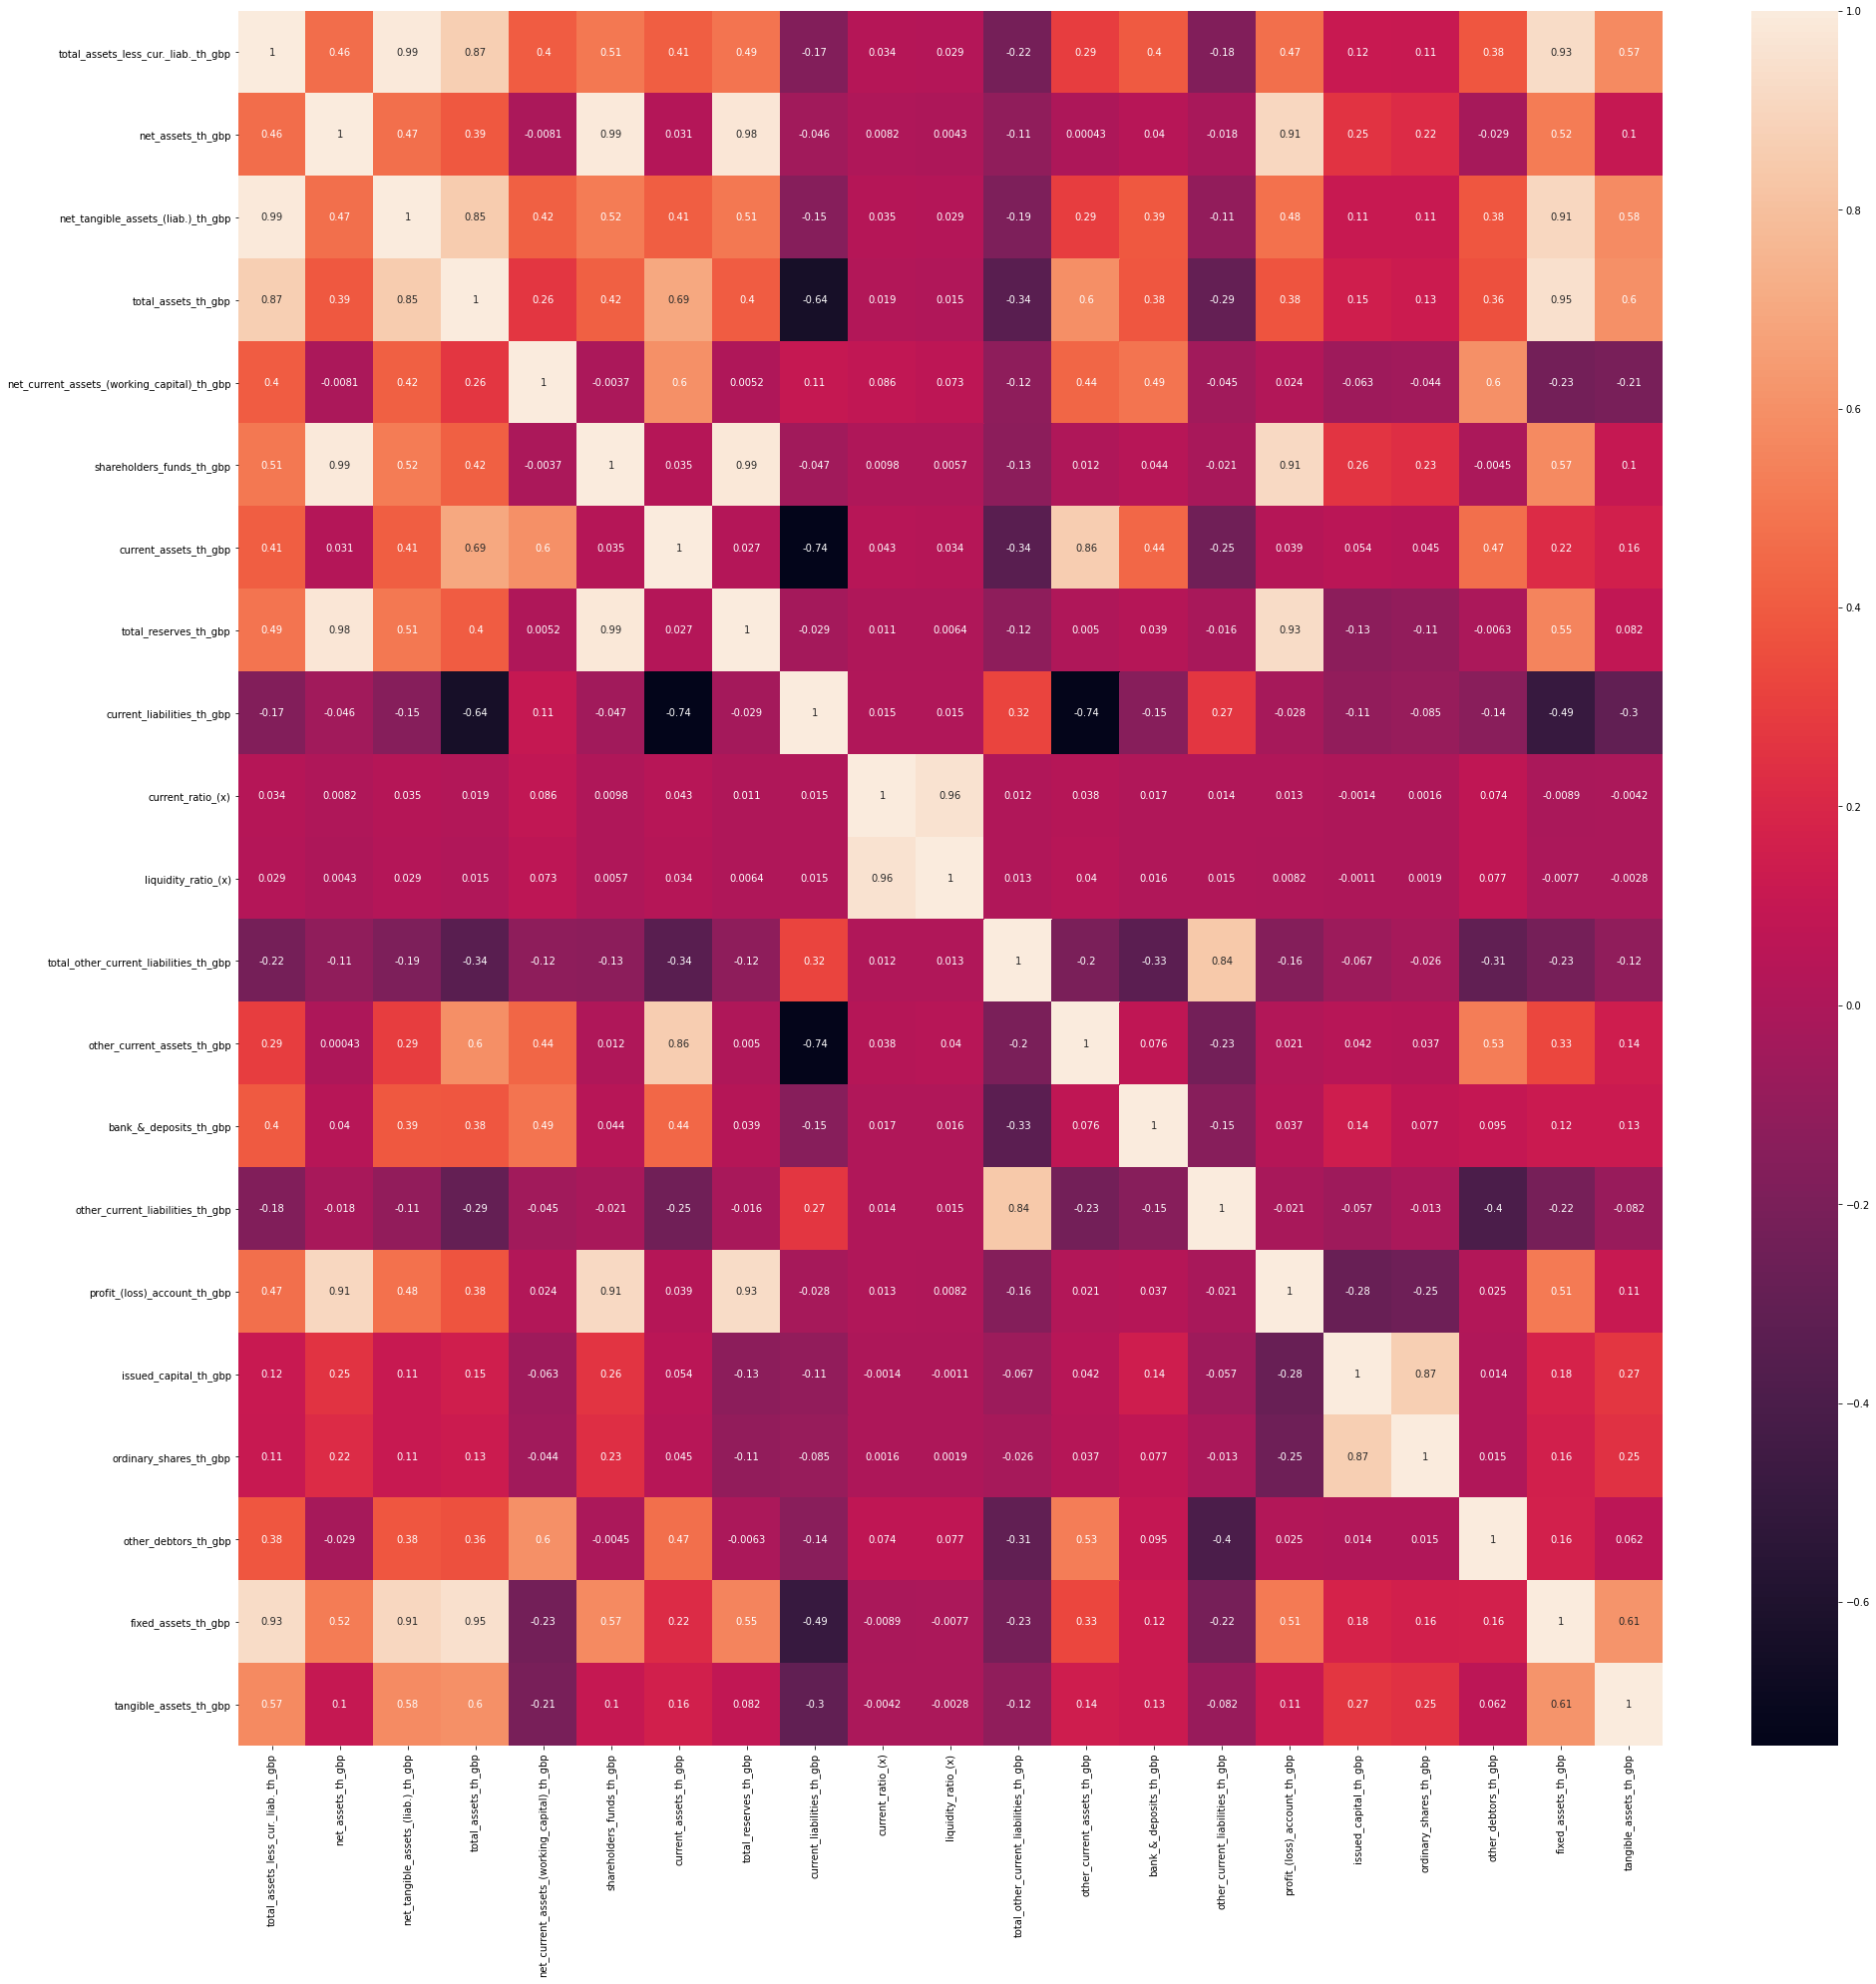

In [16]:
plt.subplots(figsize=(32,32))
sb.heatmap(df2.corr(), annot = True)

In [17]:
Q1 = df2.quantile(0.25)
Q3 = df2.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

total_assets_less_cur._liab._th_gbp            22.400750
net_assets_th_gbp                              10.965000
net_tangible_assets_(liab.)_th_gbp             20.812500
total_assets_th_gbp                            72.620750
net_current_assets_(working_capital)_th_gbp    13.107000
shareholders_funds_th_gbp                      11.713000
current_assets_th_gbp                          49.472500
total_reserves_th_gbp                          13.686500
current_liabilities_th_gbp                     48.534500
current_ratio_(x)                               1.254402
liquidity_ratio_(x)                             1.303630
total_other_current_liabilities_th_gbp         36.409000
other_current_assets_th_gbp                    30.295500
bank_&_deposits_th_gbp                         23.471000
other_current_liabilities_th_gbp               34.496500
profit_(loss)_account_th_gbp                   12.767500
issued_capital_th_gbp                           0.099000
ordinary_shares_th_gbp         

In [18]:
df2.shape

(56584, 21)

In [19]:
df3 = df2[~((df2 < (Q1 - 1.5 * IQR)) |(df2 > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df3.shape)

(32291, 21)


In [20]:
df3.isnull().sum()

total_assets_less_cur._liab._th_gbp              109
net_assets_th_gbp                                325
net_tangible_assets_(liab.)_th_gbp               350
total_assets_th_gbp                              429
net_current_assets_(working_capital)_th_gbp      501
shareholders_funds_th_gbp                        752
current_assets_th_gbp                           1111
total_reserves_th_gbp                           3949
current_liabilities_th_gbp                      5673
current_ratio_(x)                               6396
liquidity_ratio_(x)                             6484
total_other_current_liabilities_th_gbp          6480
other_current_assets_th_gbp                    12457
bank_&_deposits_th_gbp                          8390
other_current_liabilities_th_gbp                9909
profit_(loss)_account_th_gbp                    9306
issued_capital_th_gbp                           9044
ordinary_shares_th_gbp                          9097
other_debtors_th_gbp                          

In [21]:
print(df3.shape)
df3.isnull().sum()

(32291, 21)


total_assets_less_cur._liab._th_gbp              109
net_assets_th_gbp                                325
net_tangible_assets_(liab.)_th_gbp               350
total_assets_th_gbp                              429
net_current_assets_(working_capital)_th_gbp      501
shareholders_funds_th_gbp                        752
current_assets_th_gbp                           1111
total_reserves_th_gbp                           3949
current_liabilities_th_gbp                      5673
current_ratio_(x)                               6396
liquidity_ratio_(x)                             6484
total_other_current_liabilities_th_gbp          6480
other_current_assets_th_gbp                    12457
bank_&_deposits_th_gbp                          8390
other_current_liabilities_th_gbp                9909
profit_(loss)_account_th_gbp                    9306
issued_capital_th_gbp                           9044
ordinary_shares_th_gbp                          9097
other_debtors_th_gbp                          

In [22]:
df4 = df3.fillna(df3.mean())

In [23]:
df4.isnull().sum()

total_assets_less_cur._liab._th_gbp            0
net_assets_th_gbp                              0
net_tangible_assets_(liab.)_th_gbp             0
total_assets_th_gbp                            0
net_current_assets_(working_capital)_th_gbp    0
shareholders_funds_th_gbp                      0
current_assets_th_gbp                          0
total_reserves_th_gbp                          0
current_liabilities_th_gbp                     0
current_ratio_(x)                              0
liquidity_ratio_(x)                            0
total_other_current_liabilities_th_gbp         0
other_current_assets_th_gbp                    0
bank_&_deposits_th_gbp                         0
other_current_liabilities_th_gbp               0
profit_(loss)_account_th_gbp                   0
issued_capital_th_gbp                          0
ordinary_shares_th_gbp                         0
other_debtors_th_gbp                           0
fixed_assets_th_gbp                            0
tangible_assets_th_g

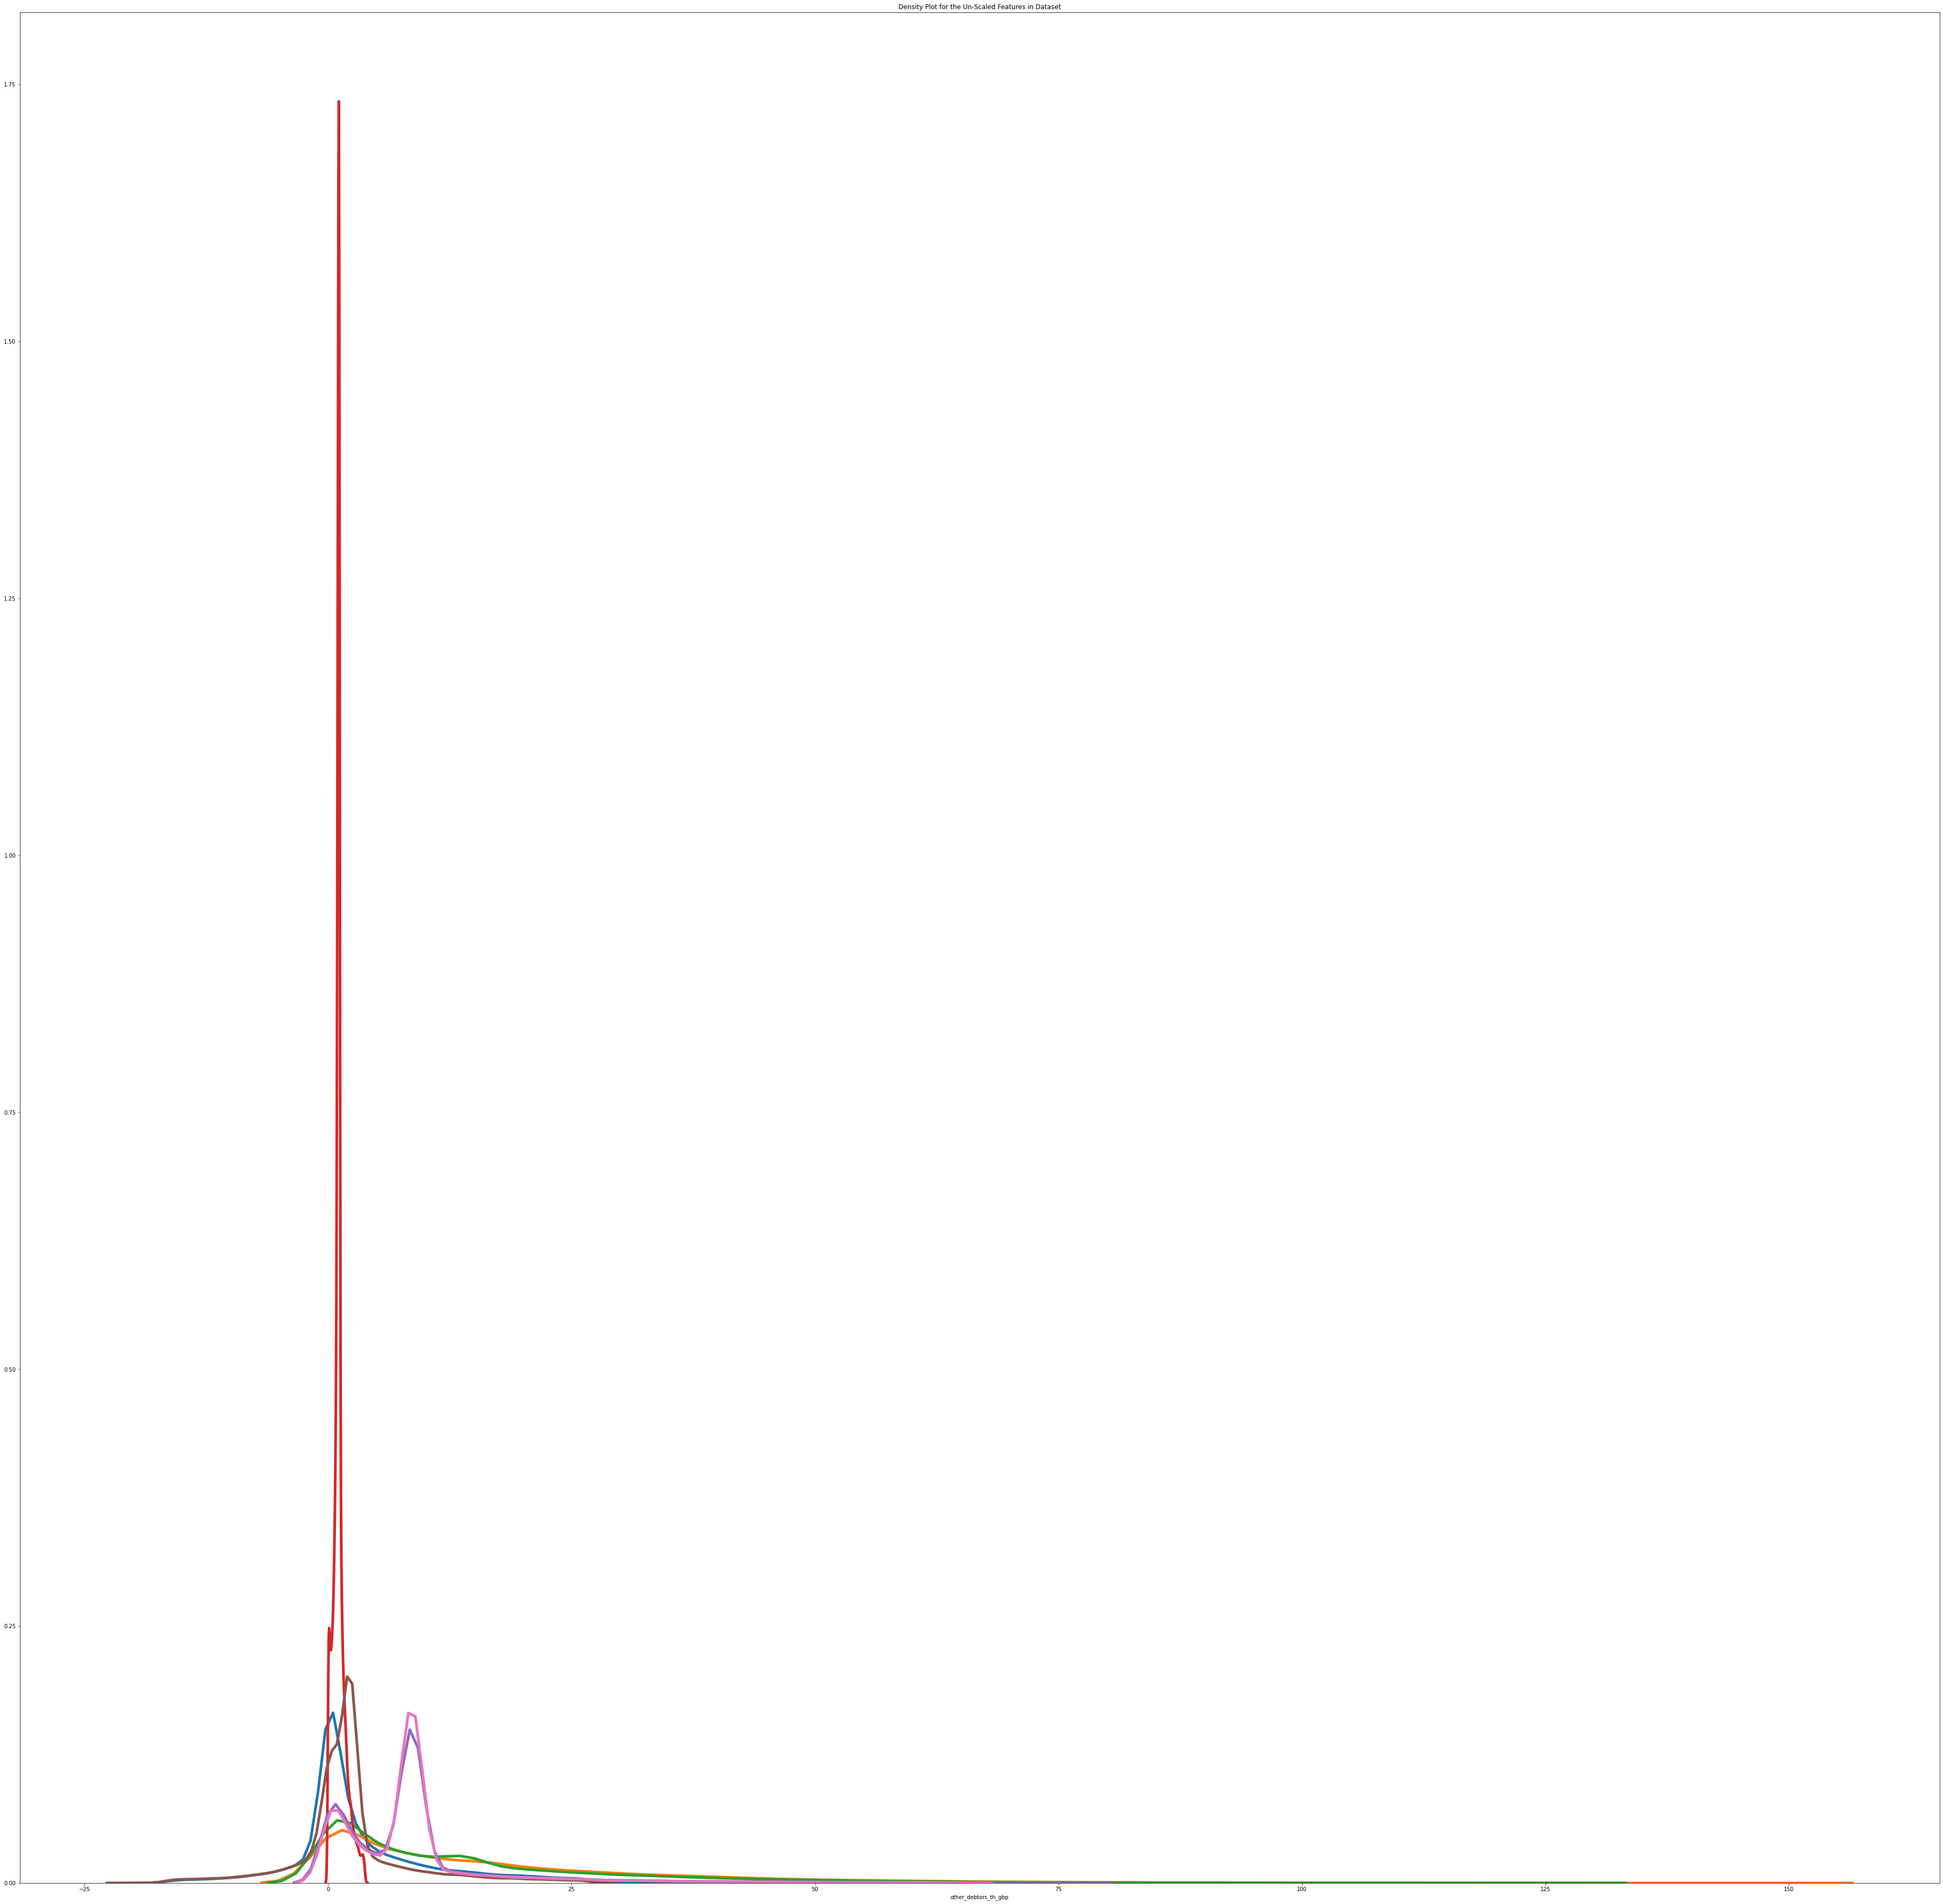

In [24]:
plt.figure(figsize=(64,64))
plt.title('Density Plot for the Un-Scaled Features in Dataset')
for c in df4.columns[0:19:3]:
    # Draw the density plot
    sb.distplot(df4[c], hist = False, kde = True,
                 kde_kws = {'linewidth': 5})

In [25]:
all_yZ = pd.DataFrame(data=Y.loc[df4.index]['up'], index=df4.index)
all_yZ.head(12)


,up
0,False
1,True
2,True
3,False
5,True
8,True
12,True
16,False
17,False
18,True


In [26]:
y_hot = pd.DataFrame(data=to_categorical(all_yZ, num_classes = 2), index=all_yZ.index)
print(y_hot.shape)
y_hot.head(12)

(32291, 2)


,0,1
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
5,0.0,1.0
8,0.0,1.0
12,0.0,1.0
16,1.0,0.0
17,1.0,0.0
18,0.0,1.0


In [27]:
X_test = df4.sample(frac=0.20, replace=True, random_state=1)
X_test.head(12)


,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp,net_tangible_assets_(liab.)_th_gbp,total_assets_th_gbp,net_current_assets_(working_capital)_th_gbp,shareholders_funds_th_gbp,current_assets_th_gbp,total_reserves_th_gbp,current_liabilities_th_gbp,current_ratio_(x),...,total_other_current_liabilities_th_gbp,other_current_assets_th_gbp,bank_&_deposits_th_gbp,other_current_liabilities_th_gbp,profit_(loss)_account_th_gbp,issued_capital_th_gbp,ordinary_shares_th_gbp,other_debtors_th_gbp,fixed_assets_th_gbp,tangible_assets_th_gbp
50712,8.897,0.000,8.897,18.683,8.479,2.127525,18.265,2.337467,-9.786,1.866442,...,-9.786000,1.163000,8.0536,-13.018155,2.255465,0.036629,0.036597,1.163000,0.418000,0.418000
358,23.807,23.807,23.807,24.383,1.307,23.807000,1.883,23.807000,-0.576,3.269097,...,-0.576000,1.883000,8.0536,-0.576000,2.255465,0.036629,0.036597,0.384000,22.500000,22.500000
20310,6.012,6.012,6.012,11.970,3.317,6.012000,9.275,6.012000,-5.958,1.556730,...,-5.958000,9.275000,8.0536,-5.958000,2.255465,0.036629,0.036597,9.275000,2.695000,2.695000
8820,0.432,0.432,0.432,4.090,0.233,0.432000,3.891,0.431000,-3.658,1.063696,...,-3.658000,3.424000,0.4670,-3.658000,0.431000,0.001000,0.001000,3.424000,0.199000,0.199000
28944,7.515,7.515,7.515,19.465,0.985,7.515000,12.935,7.513000,-11.950,1.082427,...,-11.950000,5.344000,5.7160,-11.950000,7.513000,0.002000,0.002000,5.344000,6.530000,6.530000
18265,0.001,0.001,0.001,2.273,0.001,0.001000,2.273,2.337467,-2.272,1.000440,...,-2.272000,8.600857,2.2730,-2.272000,2.255465,0.001000,0.001000,8.580419,4.475735,4.139005
13150,0.196,0.196,0.196,1.582,0.196,0.196000,1.582,0.196000,-1.386,1.141414,...,-1.386000,1.582000,8.0536,-1.386000,2.255465,0.036629,0.036597,1.582000,4.475735,4.139005
32291,0.549,0.549,0.549,0.849,0.549,2.127525,0.849,2.337467,-0.300,2.830000,...,-0.300000,0.300000,0.5490,-13.018155,2.255465,0.036629,0.036597,8.580419,4.475735,4.139005
35760,0.226,0.226,0.226,14.195,-0.585,0.226000,13.384,0.225000,-13.969,0.958122,...,-13.969000,12.850000,0.5340,-13.969000,0.225000,0.001000,0.001000,12.850000,0.811000,0.811000
246,11.850,11.850,11.850,16.450,3.200,11.850000,7.800,11.850000,-4.600,1.695652,...,-13.661533,8.600857,7.8000,-13.018155,11.850000,0.036629,0.036597,8.580419,8.650000,8.650000


In [28]:
Y_test = pd.DataFrame(data=Y.loc[X_test.index]['up'], index=X_test.index)
Y_test.head(12)

,up
50712,False
358,False
20310,False
8820,True
28944,True
18265,False
13150,True
32291,False
35760,False
246,True


In [29]:
X_train = df4.drop(X_test.index)
X_train.head(12)

,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp,net_tangible_assets_(liab.)_th_gbp,total_assets_th_gbp,net_current_assets_(working_capital)_th_gbp,shareholders_funds_th_gbp,current_assets_th_gbp,total_reserves_th_gbp,current_liabilities_th_gbp,current_ratio_(x),...,total_other_current_liabilities_th_gbp,other_current_assets_th_gbp,bank_&_deposits_th_gbp,other_current_liabilities_th_gbp,profit_(loss)_account_th_gbp,issued_capital_th_gbp,ordinary_shares_th_gbp,other_debtors_th_gbp,fixed_assets_th_gbp,tangible_assets_th_gbp
0,-0.505,-0.505,-0.505,32.892,-0.505,-0.505,32.892,-0.506000,-33.397000,0.984879,...,-33.397000,32.814000,0.0780,-33.397000,-0.506000,0.001000,0.001000,32.814000,4.475735,4.139005
1,-2.561,-2.561,-2.561,33.273,-2.561,-2.561,33.273,-2.562000,-35.834000,0.928532,...,-35.834000,33.148000,0.1250,-35.834000,-2.562000,0.001000,0.001000,33.148000,4.475735,4.139005
2,7.658,7.658,7.658,59.282,7.658,7.658,59.282,7.657000,-51.624000,1.148342,...,-51.624000,32.561000,9.9710,-51.624000,7.657000,0.001000,0.001000,32.561000,4.475735,4.139005
3,21.344,21.344,21.344,66.893,16.693,21.344,62.242,21.343000,-45.549000,1.366484,...,-43.181000,8.600857,23.4740,-30.773000,21.343000,0.001000,0.001000,8.580419,4.651000,4.651000
5,22.798,22.798,22.798,69.024,18.540,22.798,64.766,22.797000,-46.226000,1.401073,...,-46.226000,20.000000,30.2460,-46.226000,22.797000,0.001000,0.001000,20.000000,4.258000,4.258000
8,13.830,-6.493,13.830,16.028,5.803,-6.493,8.001,-6.593000,-2.198000,3.640127,...,-2.198000,8.600857,8.0010,-2.198000,-6.593000,0.100000,0.100000,8.580419,8.027000,8.027000
12,36.972,8.915,32.958,36.972,5.580,8.915,5.580,8.815000,-15.385215,1.125907,...,-13.661533,5.580000,8.0536,-13.018155,8.815000,0.100000,0.100000,5.580000,31.392000,2.862000
16,0.002,0.002,0.002,0.002,0.002,0.002,0.002,2.337467,-15.385215,1.125907,...,-13.661533,0.002000,8.0536,-13.018155,2.255465,0.002000,0.002000,0.002000,4.475735,4.139005
17,0.002,0.002,0.002,0.002,0.002,0.002,0.002,2.337467,-15.385215,1.125907,...,-13.661533,0.002000,8.0536,-13.018155,2.255465,0.002000,0.002000,0.002000,4.475735,4.139005
18,-2.995,-2.995,-2.995,13.902,-8.541,-2.995,8.356,-2.997000,-16.897000,0.494526,...,-16.897000,5.684000,2.6720,-16.897000,-2.997000,0.002000,0.002000,5.684000,5.546000,5.546000


In [30]:
Y_train = pd.DataFrame(data=Y.loc[X_train.index]['up'], index=X_train.index)
Y_train.head(12)

,up
0,False
1,True
2,True
3,False
5,True
8,True
12,True
16,False
17,False
18,True


### Is Dataset balanced between categories?

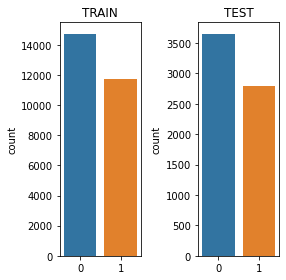

In [31]:
map_characters = {0: 'No Growth', 1: 'Yes Growth'}
plt.subplot(1,3,1)
sb.countplot(np.argmax(to_categorical(Y_train, num_classes = 2), axis=1)).set_title('TRAIN')
plt.subplot(1,3,2)
sb.countplot(np.argmax(to_categorical(Y_test, num_classes = 2), axis=1)).set_title('TEST')
plt.tight_layout()


In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_trn = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
X_tst = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
print("X_trn shape: ",X_trn.shape)
print("X_tst shape: ",X_tst.shape)

X_trn shape:  (26444, 21)
X_tst shape:  (6458, 21)


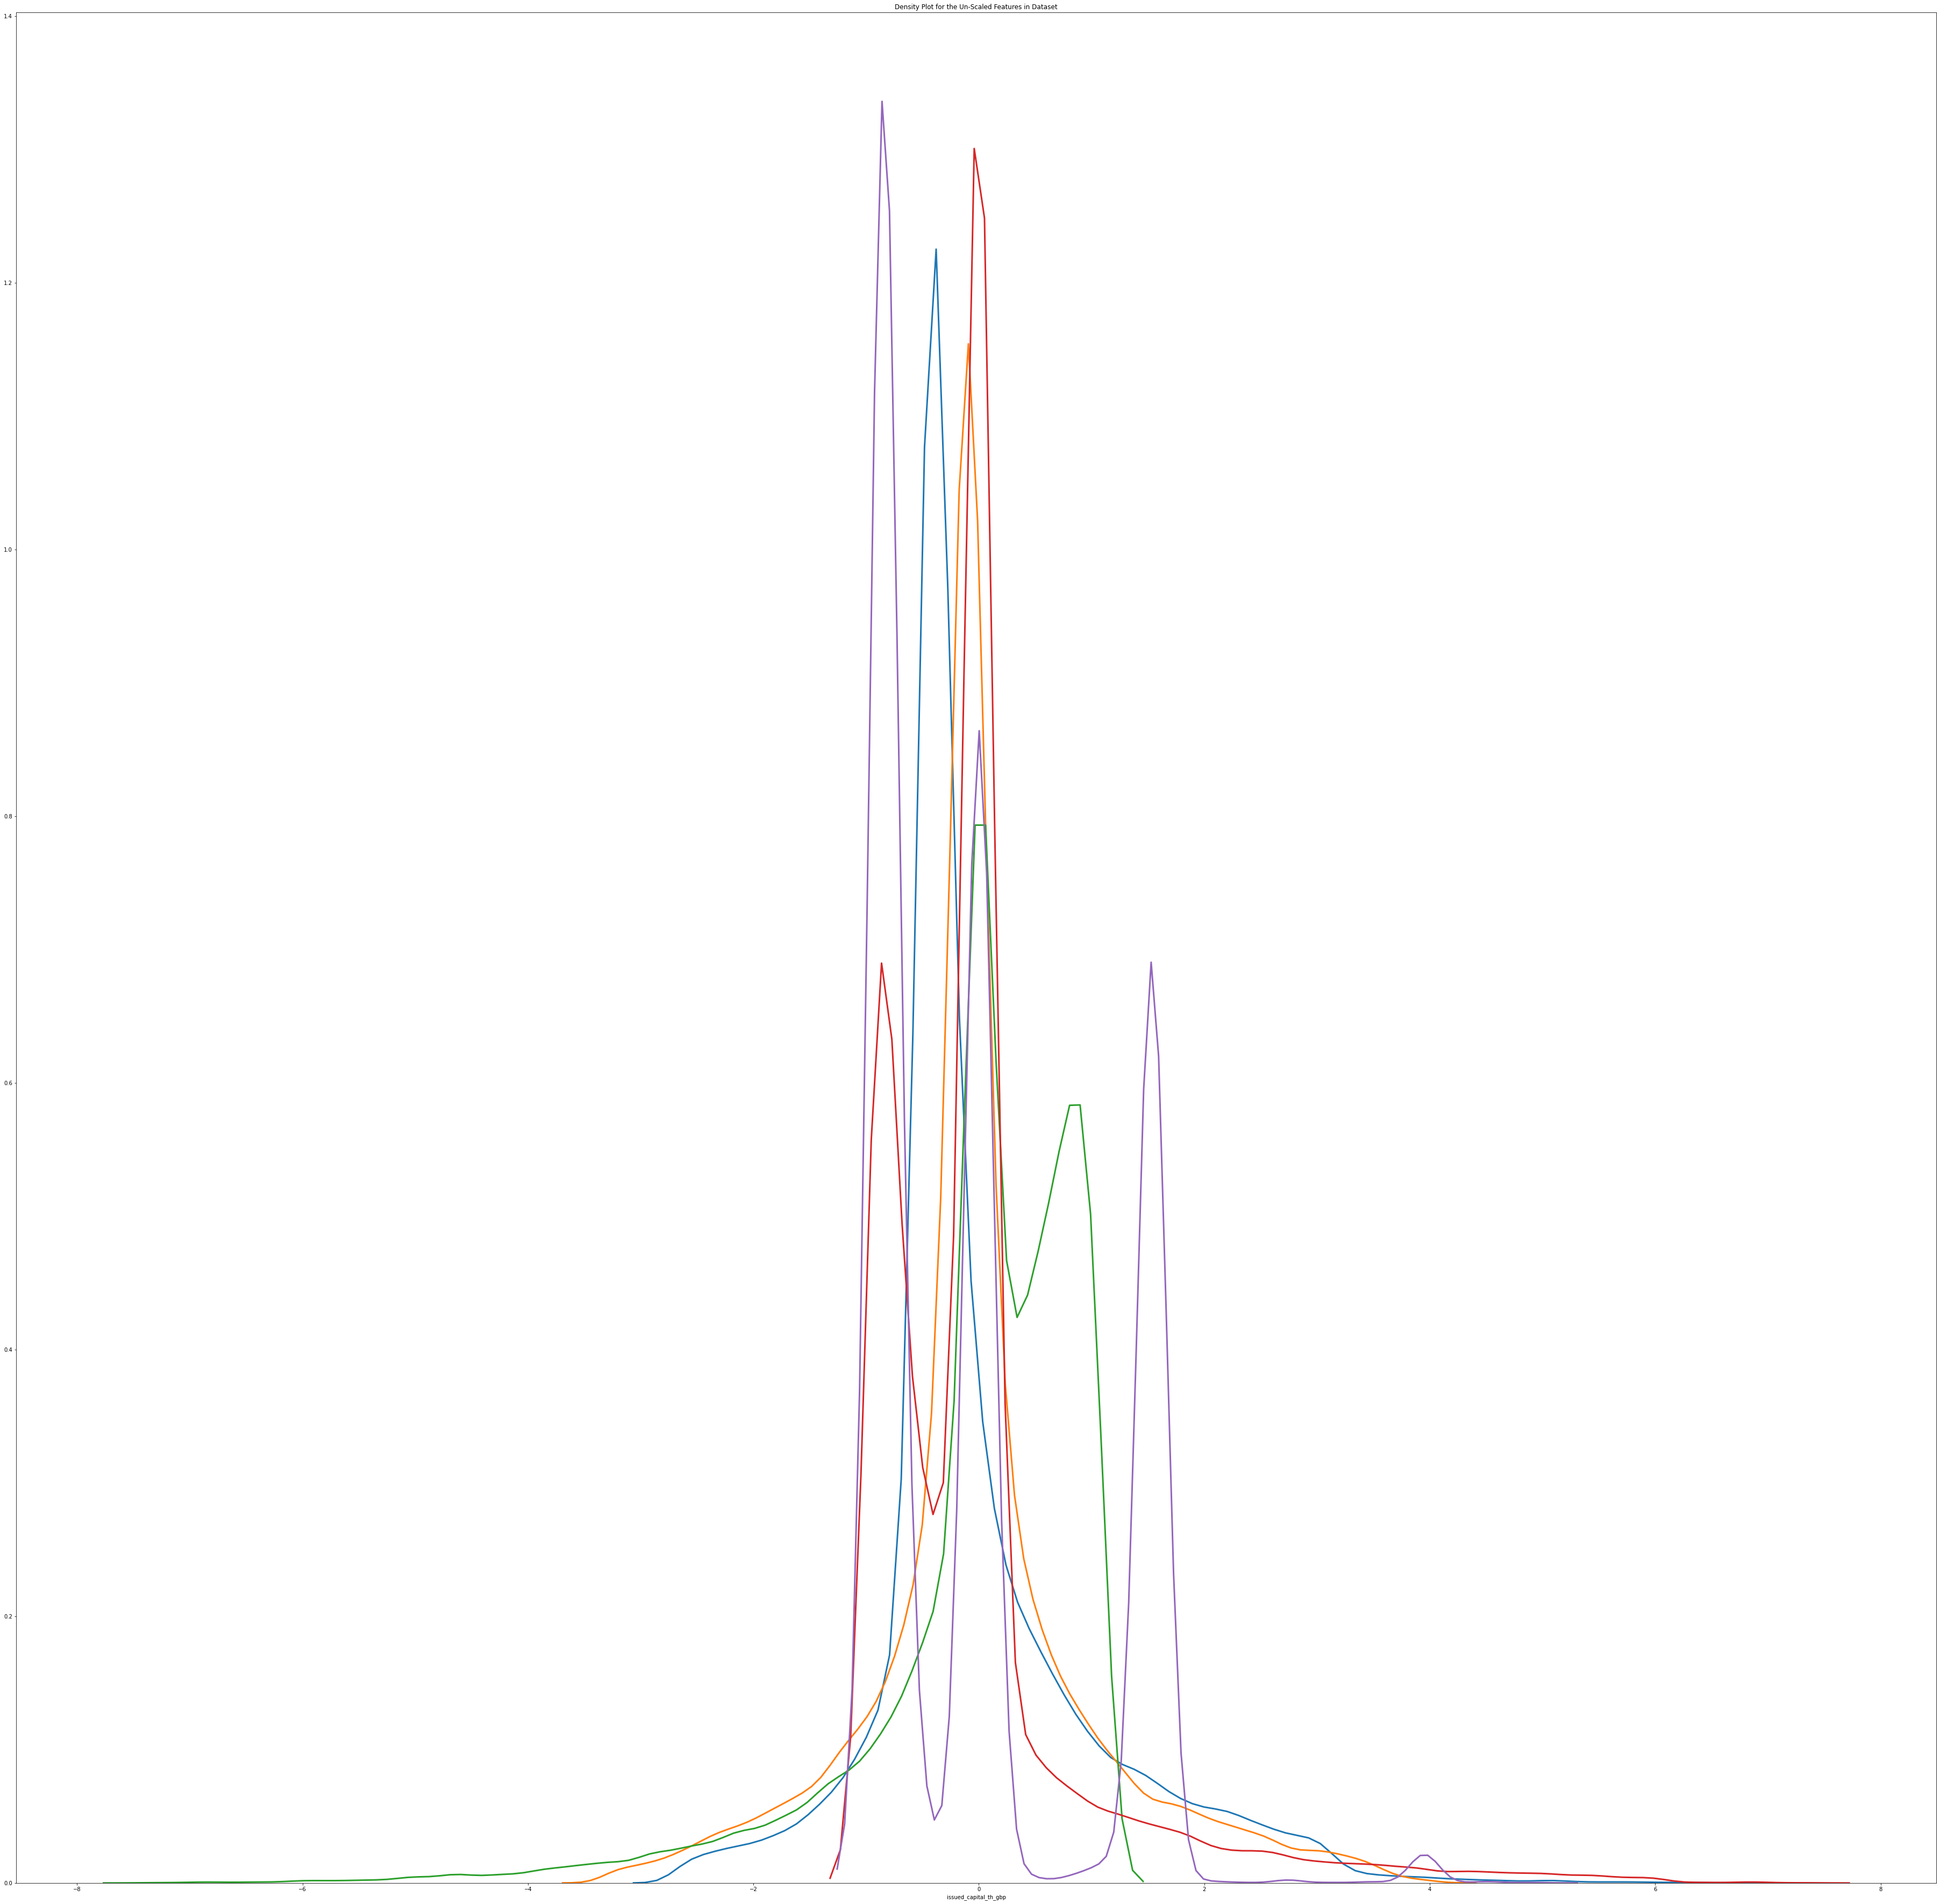

In [33]:
plt.figure(figsize=(64,64))
plt.title('Density Plot for the Un-Scaled Features in Dataset')
for c in X_trn.columns[0:19:4]:
    # Draw the density plot
    sb.distplot(X_trn[c], hist = False, kde = True,
                 kde_kws = {'linewidth': 3})

In [34]:
X_trn.head(12)

,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp,net_tangible_assets_(liab.)_th_gbp,total_assets_th_gbp,net_current_assets_(working_capital)_th_gbp,shareholders_funds_th_gbp,current_assets_th_gbp,total_reserves_th_gbp,current_liabilities_th_gbp,current_ratio_(x),...,total_other_current_liabilities_th_gbp,other_current_assets_th_gbp,bank_&_deposits_th_gbp,other_current_liabilities_th_gbp,profit_(loss)_account_th_gbp,issued_capital_th_gbp,ordinary_shares_th_gbp,other_debtors_th_gbp,fixed_assets_th_gbp,tangible_assets_th_gbp
0,-0.506726,-0.392293,-0.476675,0.917108,-0.188772,-0.396896,1.156936,-0.430730,-1.242873,-0.226345,...,-1.548688,2.606394,-0.872489,-1.695558,-0.467970,-0.858812,-0.859107,2.751145,0.004208,0.002360
1,-0.779756,-0.699201,-0.751743,0.938080,-0.475995,-0.704189,1.180309,-0.739759,-1.411331,-0.316005,...,-1.740250,2.642373,-0.867363,-1.898731,-0.813468,-0.858812,-0.859107,2.789075,0.004208,0.002360
2,0.577293,0.826231,0.615434,2.369733,0.951600,0.823156,2.775816,0.796221,-2.502820,0.033757,...,-2.981435,2.579141,0.206365,-3.215148,0.903772,-0.858812,-0.859107,2.722414,0.004208,0.002360
3,2.394749,2.869196,2.446453,2.788676,2.213791,2.868683,2.957396,2.853313,-2.082884,0.380865,...,-2.317767,-0.001857,1.678897,-1.476794,3.203619,-0.858812,-0.859107,-0.000884,0.041528,0.124916
5,2.587835,3.086241,2.640981,2.905976,2.471817,3.086000,3.112229,3.071858,-2.129681,0.435902,...,-2.557121,1.226064,2.417399,-2.765115,3.447955,-0.858812,-0.859107,1.295953,-0.042156,0.030844
8,1.396915,-1.286146,1.441172,-0.011162,0.692456,-1.291871,-0.369988,-1.345644,0.913768,3.998683,...,0.903733,-0.001857,-0.008468,0.905513,-1.490853,1.533726,1.536300,-0.000884,0.760405,0.933027
12,4.470095,1.013869,4.000264,1.141690,0.661303,1.011029,-0.518503,0.970275,0.002198,-0.001942,...,0.002633,-0.327265,-0.002732,0.003433,1.098366,1.533726,1.536300,-0.341620,5.735689,-0.303315
16,-0.439398,-0.316611,-0.408845,-0.893305,-0.117944,-0.321120,-0.860683,-0.003339,0.002198,-0.001942,...,0.002633,-0.928130,-0.002732,0.003433,-0.003923,-0.834645,-0.834911,-0.975072,0.004208,0.002360
17,-0.439398,-0.316611,-0.408845,-0.893305,-0.117944,-0.321120,-0.860683,-0.003339,0.002198,-0.001942,...,0.002633,-0.928130,-0.002732,0.003433,-0.003923,-0.834645,-0.834911,-0.975072,0.004208,0.002360
18,-0.837390,-0.763986,-0.809806,-0.128187,-1.311402,-0.769055,-0.348211,-0.805143,-0.102305,-1.006595,...,-0.251693,-0.316062,-0.589607,-0.319947,-0.886567,-0.834645,-0.834911,-0.329809,0.232107,0.339152


In [ ]:
_y = to_categorical(Y_train, num_classes = 2)
num_classes = _y.shape[1]; num_features = X_trn.shape[1]
#X_tst
num_layers_0 = 16; num_layers_1 = 8
# Define the keras model
model = Sequential()
model.add(Dense(num_layers_0, input_dim=num_features, activation='relu'))
model.add(Dense(num_layers_1, activation='relu'))
model.add(Dense(num_classes, activation='sigmoid'))

class MetricsCheckpoint(Callback):
    """Callback that saves metrics after each epoch"""
    def __init__(self, savepath):
        super(MetricsCheckpoint, self).__init__()
        self.savepath = savepath
        self.history = {}
    def on_epoch_end(self, epoch, logs=None):
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
        np.save(self.savepath, self.history)


# Compile the keras model
#model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
model.compile(loss='binary_crossentropy', 
                 optimizer='adam',
                 metrics=['accuracy'])
filepath="weights-improvement-{epoch:02d}-{loss:.4f}-FafnirMLPClassifier.hdf5"
weights_improvement = ModelCheckpoint(filepath, monitor='acc', verbose=1, save_best_only=True, mode='max')
callbacks_list = [keras.callbacks.EarlyStopping(monitor='acc', patience=3, verbose=1),weights_improvement]
model.summary()
# Fit keras model


In [ ]:
from pprint import pprint
import sklearn
from sklearn.metrics import confusion_matrix
def training_report(model,history,xtest,ytest,labels={0: 'No Growth', 1: 'Yes Growth'}):
    # Evaluate model
    score = model.evaluate(xtest,ytest, verbose=0)
    print('\nKeras - accuracy:', score[1], '\n')
    pprint(score)
    y_pred = model.predict(xtest)
    #print('\n', sklearn.metrics.classification_report(np.where(ytest > 0)[1], np.argmax(y_pred, axis=1), target_names=list(labels.values())), sep='') 
    Y_pred_classes = np.argmax(y_pred,axis = 1) 
    Y_true = np.argmax(ytest,axis = 1) 
    confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
    plotKerasLearningCurve()
    plt.show()
    plot_learning_curve(history)
    plt.show()
    plot_confusion_matrix(confusion_mtx, classes = list(labels.values()))
    plt.show()

def plotKerasLearningCurve():
    plt.figure(figsize=(10,5))
    metrics = np.load('logs.npy',allow_pickle=True)[()]
    filt = ['loss'] # try to add 'loss' to see the loss learning curve
    for k in filter(lambda x : np.any([kk in x for kk in filt]), metrics.keys()):
        l = np.array(metrics[k])
        plt.plot(l, c= 'r' if 'val' not in k else 'b', label='val' if 'val' in k else 'train')
        x = np.argmin(l) if 'loss' in k else np.argmax(l)
        y = l[x]
        plt.scatter(x,y, lw=0, alpha=0.25, s=100, c='r' if 'val' not in k else 'b')
        plt.text(x, y, '{} = {:.4f}'.format(x,y), size='15', color= 'r' if 'val' not in k else 'b')   
    plt.legend(loc=4)
    plt.axis([0, None, None, None]);
    plt.grid()
    plt.xlabel('Number of epochs')
    plt.ylabel('Accuracy')

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (5,5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plot_learning_curve(history):
    plt.figure(figsize=(16,6))
    plt.subplot(1,2,1)
    plt.plot(history.history['binary_accuracy'])
    plt.plot(history.history['loss'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./accuracy_curve.png')
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./loss_curve.png')

In [ ]:
#model, history,
print(X_tst.shape)
print(y_test_one_hot.shape)



Keras - accuracy: 0.5376160740852356 

[12.116989135742188, 0.5376160740852356]


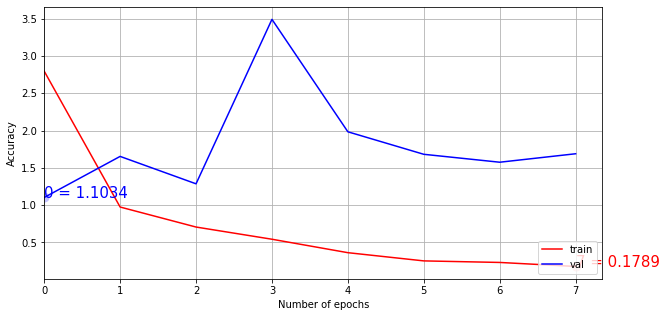

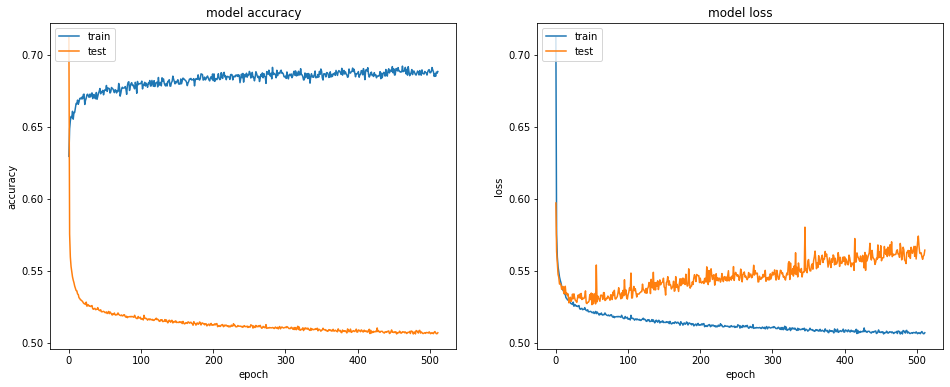

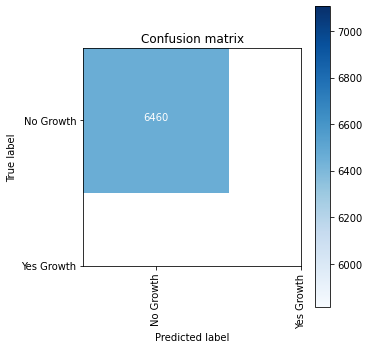

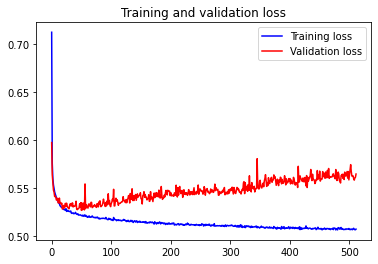

In [69]:
import itertools
training_report(model, history, X_tst, y_test_one_hot,{0: 'No Growth', 1: 'Yes Growth'})
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(512)
plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()